# 🤖 Churn Prediction Model Experiments

## 🎯 Objective
This notebook evaluates baseline machine learning models for customer churn prediction.

Goals:
- train baseline models
- compare performance across models
- evaluate using appropriate classification metrics
- identify the best candidate model for deployment

---

## 📌 Models Used
- Logistic Regression (baseline)
- Random Forest (non-linear model)

---

## 📊 Evaluation Metrics
- ROC-AUC (primary metric)
- F1-score
- Recall
- Precision

In [1]:
# 2. Import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_curve
)

sns.set(style="whitegrid")

## 1. Load Processed Data

We reuse the preprocessing pipeline from `02_feature_engineering.ipynb`.

In [2]:
# 4. Load data and rebuild preprocessing pipeline

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

data_path = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(data_path)

# preprocessing (same as previous notebook)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().copy()
df["Churn_binary"] = df["Churn"].map({"No": 0, "Yes": 1})

target_col = "Churn_binary"
exclude_cols = ["customerID", "Churn", target_col]

X = df[[col for col in df.columns if col not in exclude_cols]]
y = df[target_col]

# feature split
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

if "SeniorCitizen" in numeric_features:
    numeric_features.remove("SeniorCitizen")
    categorical_features.append("SeniorCitizen")

# split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)

# dense 변환
if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
if hasattr(X_valid, "toarray"):
    X_valid = X_valid.toarray()

## 2. Logistic Regression (Baseline Model)

In [4]:
# 6. Train Logistic Regression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_valid)
lr_proba = lr_model.predict_proba(X_valid)[:, 1]

In [5]:
# 7. Evaluate Logistic Regression

lr_metrics = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_valid, lr_pred),
    "precision": precision_score(y_valid, lr_pred),
    "recall": recall_score(y_valid, lr_pred),
    "f1": f1_score(y_valid, lr_pred),
    "roc_auc": roc_auc_score(y_valid, lr_proba)
}

lr_metrics

{'model': 'Logistic Regression',
 'accuracy': 0.8045486851457001,
 'precision': 0.649546827794562,
 'recall': 0.5748663101604278,
 'f1': 0.6099290780141844,
 'roc_auc': np.float64(0.8359342240812545)}

### Interpretation
- Logistic Regression provides a simple baseline.
- It is interpretable but may struggle with non-linear relationships.

## 3. Random Forest (Non-linear Model)

In [6]:
# 10. Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)
rf_proba = rf_model.predict_proba(X_valid)[:, 1]

In [7]:
# 11. Evaluate Random Forest

rf_metrics = {
    "model": "Random Forest",
    "accuracy": accuracy_score(y_valid, rf_pred),
    "precision": precision_score(y_valid, rf_pred),
    "recall": recall_score(y_valid, rf_pred),
    "f1": f1_score(y_valid, rf_pred),
    "roc_auc": roc_auc_score(y_valid, rf_proba)
}

rf_metrics

{'model': 'Random Forest',
 'accuracy': 0.7889125799573561,
 'precision': 0.6296296296296297,
 'recall': 0.5,
 'f1': 0.5573770491803278,
 'roc_auc': np.float64(0.8285159263036377)}

### Interpretation
- Random Forest captures non-linear interactions.
- Typically improves performance over linear models.

## 4. Model Comparison

In [8]:
# 14. Compare models

results = pd.DataFrame([lr_metrics, rf_metrics])
results

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.788913,0.629630,0.500000,0.557377,0.828516


In [12]:
# 14-1. Sort results by primary metric

results.sort_values(by="roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.788913,0.629630,0.500000,0.557377,0.828516


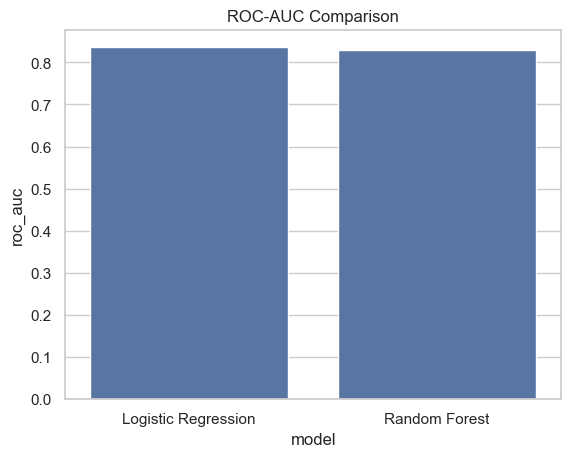

In [9]:
# 15. Visualize ROC-AUC comparison

sns.barplot(x="model", y="roc_auc", data=results)
plt.title("ROC-AUC Comparison")
plt.show()

### Interpretation
- ROC-AUC is the primary metric.
- Higher ROC-AUC indicates better ranking ability.

## 5. ROC Curve Analysis

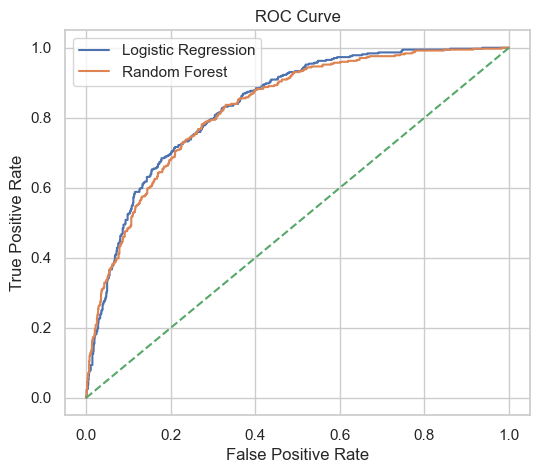

In [10]:
# 18. ROC curves

fpr_lr, tpr_lr, _ = roc_curve(y_valid, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_valid, rf_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [13]:
# Feature importance for Random Forest

feature_names = preprocessor.get_feature_names_out()

rf_feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_feature_importance.head(15)

,feature,importance
0,num__tenure,0.143528
2,num__TotalCharges,0.121847
35,cat__Contract_Month-to-month,0.095903
1,num__MonthlyCharges,0.088895
17,cat__OnlineSecurity_No,0.048598
26,cat__TechSupport_No,0.043069
15,cat__InternetService_Fiber optic,0.042506
42,cat__PaymentMethod_Electronic check,0.039516
37,cat__Contract_Two year,0.035763
20,cat__OnlineBackup_No,0.021285


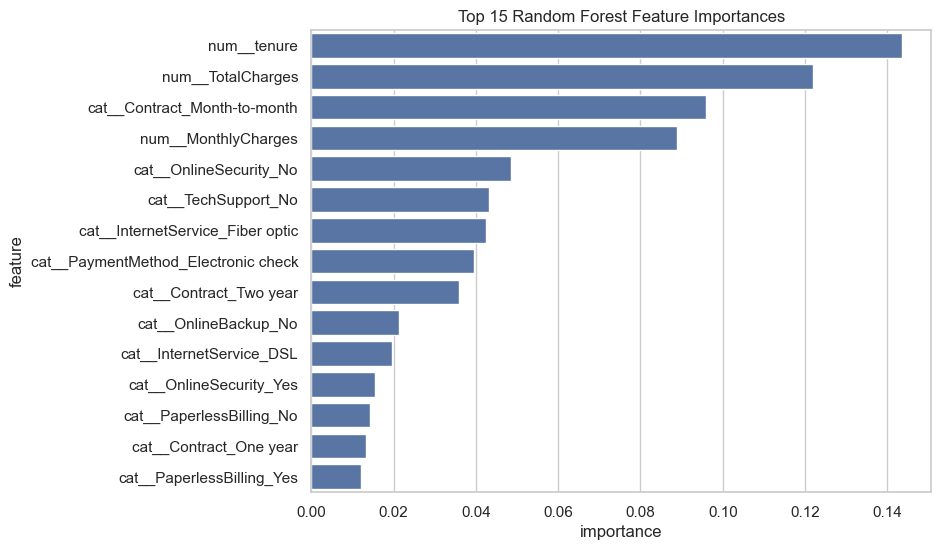

In [14]:
# Visualize top feature importances

top_n = 15
top_features = rf_feature_importance.head(top_n)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

### Interpretation
- ROC curve shows model performance across all thresholds.
- A curve closer to the top-left indicates better performance.

## 6. Threshold Insight

In [15]:
# 21. Default threshold vs custom threshold

threshold = 0.3
rf_pred_custom = (rf_proba >= threshold).astype(int)

print("Default Precision:", precision_score(y_valid, rf_pred))
print("Default Recall:", recall_score(y_valid, rf_pred))
print("Custom Precision (0.3):", precision_score(y_valid, rf_pred_custom))
print("Custom Recall (0.3):", recall_score(y_valid, rf_pred_custom))

Default Precision: 0.6296296296296297
Default Recall: 0.5
Custom Precision (0.3): 0.5106761565836299
Custom Recall (0.3): 0.767379679144385


### Interpretation
- Lowering the threshold increases recall.
- This is useful when detecting churn is more important than precision.

## 📌 Final Conclusion

- Logistic Regression serves as a strong and interpretable baseline model.
- Random Forest achieved solid validation performance and appears to be the stronger candidate in this experiment.
- In particular, Random Forest reached a ROC-AUC of about 0.83, making it a strong model for ranking churn risk.
- However, recall at the default threshold is still limited, so threshold tuning is important when churn detection is prioritized.

---

## 🚀 Next Step

- compare Logistic Regression and Random Forest more explicitly in a results table
- tune Random Forest hyperparameters
- examine feature importance
- prepare the best model for packaging and inference